### Climate Change in Brookhaven, New York

This notebook looks at the change in temperature over time in Brookhaven, New York. The data used in this project are from the UPTON COOP NWSFO NEW YORK station (USC00308721) and were downloaded from the Global Historical Climatology Network daily (GHCNd). Brookhaven is a town located in central Long Island and is home to Brookhaven National Laboratory. Long Island, in general, is a mostly flat, densely population region. Barrier islands along the south shore help protect Long Island from storms, which are increasing in frequency and intensity due to climate change. The climate of the area is characterized by hot, humid summers and cool winters (Dike & Tilburg, 2007).

In [1]:
### Import libraries

### Bring in pandas to work with tabular data
import pandas as pd

### Libraries for visualization
import holoviews as hv
import hvplot.pandas
import hvplot

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### get r2 and p value
import numpy as np

In [2]:
### install library not in environment
! pip install statsmodels

### import library
import statsmodels.api as sm

### Bring in and Wrangle Data

#### Data Type Note

The temperature at the time of observation (TOBS) was used to look at the trend in temperature change in Brookhaven. The period of record for this data type at this station starts in 12/12/1995 and is ongoing. The date range chosen for this analysis was 1/1/1996 to 12/31/2025. Later in this analysis, the data will be resampled to annual averages, so this date range ensures that temperature data for a full year is averaged.

In [3]:
### Make url data for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00308721'
            '&startDate=1996-01-01&endDate=2025-12-31&units=standard')
### See url
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00308721&startDate=1996-01-01&endDate=2025-12-31&units=standard'

In [4]:
### get the data using the URL
newyork_temp_df = pd.read_csv(
    ncei_url,

    ### tells python which column to use as the index
    index_col = 'DATE',

    ### tells python to treat values in DATE as dates
    parse_dates = True,

    ### tells python what the na values are
    na_values = ['NaN']
)

### See Long Island, New York temp df
newyork_temp_df


,STATION,TOBS
DATE,,
1996-01-01,USC00308721,NaN
1996-01-02,USC00308721,34.0
1996-01-03,USC00308721,31.0
1996-01-04,USC00308721,19.0
1996-01-05,USC00308721,9.0
...,...,...
2025-12-27,USC00308721,26.0
2025-12-28,USC00308721,14.0
2025-12-29,USC00308721,44.0


In [5]:
### save the climate data as csv
newyork_temp_df.to_csv('newyork_temp_data.csv')

In [6]:
### remove the station ID column to simplify the dataframe
newyork_temp_only_df = newyork_temp_df[['TOBS']]

### open temp only dataframe
newyork_temp_only_df

,TOBS
DATE,
1996-01-01,NaN
1996-01-02,34.0
1996-01-03,31.0
1996-01-04,19.0
1996-01-05,9.0
...,...
2025-12-27,26.0
2025-12-28,14.0
2025-12-29,44.0


In [7]:
### Verify units and give more detailed column name

### double check the units are degrees F
newyork_temp_only_df['TOBS'].agg(['min', 'max'])

### change TOBS column name to clarify units
ny_temp_units_df = newyork_temp_only_df.rename(columns={
    'TOBS': 'temp_f',
})

### open temp f dataframe
ny_temp_units_df

,temp_f
DATE,
1996-01-01,NaN
1996-01-02,34.0
1996-01-03,31.0
1996-01-04,19.0
1996-01-05,9.0
...,...
2025-12-27,26.0
2025-12-28,14.0
2025-12-29,44.0


#### Unit Check
The max temperature of 44.0 indicates that this data is in &deg;F.

In [8]:
### Convert units

### create function to convert F to C
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f-32)*5/9

### apply function
ny_temp_units_df['temp_c']=(
    ny_temp_units_df['temp_f'].apply(convert_f_to_c)
)

### open dataframe
ny_temp_units_df

,temp_f,temp_c
DATE,,
1996-01-01,NaN,NaN
1996-01-02,34.0,1.111111
1996-01-03,31.0,-0.555556
1996-01-04,19.0,-7.222222
1996-01-05,9.0,-12.777778
...,...,...
2025-12-27,26.0,-3.333333
2025-12-28,14.0,-10.000000
2025-12-29,44.0,6.666667


### Plot the Results

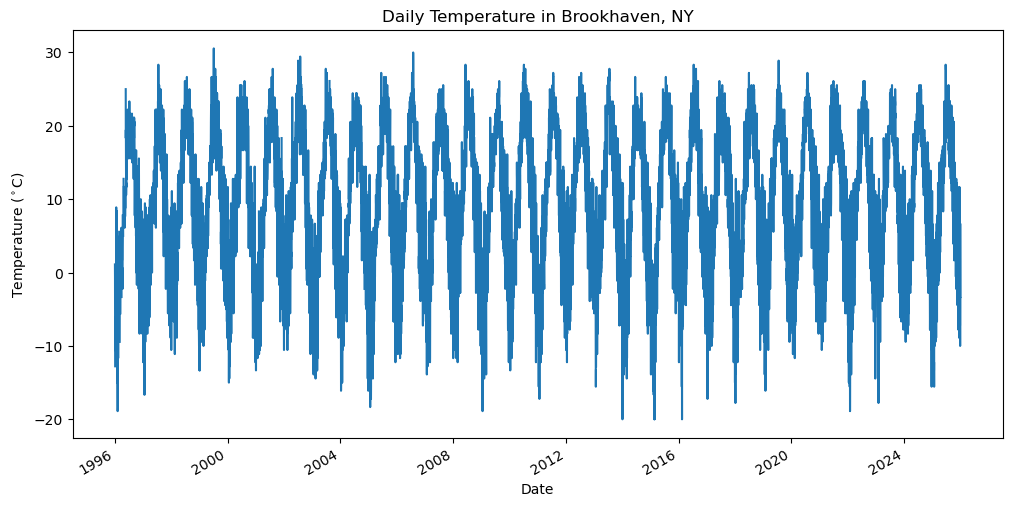

In [9]:
### plot the data

### create no legend object that is the daily temp plot
no_legend = ny_temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Brookhaven, NY',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize= (12,6))

### call the no legend object and tell it to remove the legend
no_legend.legend().remove()


In [10]:
### create new dataframe and resample data to show mean annual temperatures and create graph with better resolution
ny_ann_temp_df = (
    ny_temp_units_df
    .resample('YS')
    .mean()
)

ny_ann_temp_df

,temp_f,temp_c
DATE,,
1996-01-01,47.510067,8.616704
1997-01-01,46.088154,7.826752
1998-01-01,50.240331,10.133517
1999-01-01,49.764384,9.869102
2000-01-01,47.548209,8.637894
2001-01-01,49.019553,9.455307
2002-01-01,49.744444,9.858025
2003-01-01,47.126404,8.403558
2004-01-01,47.848315,8.804619


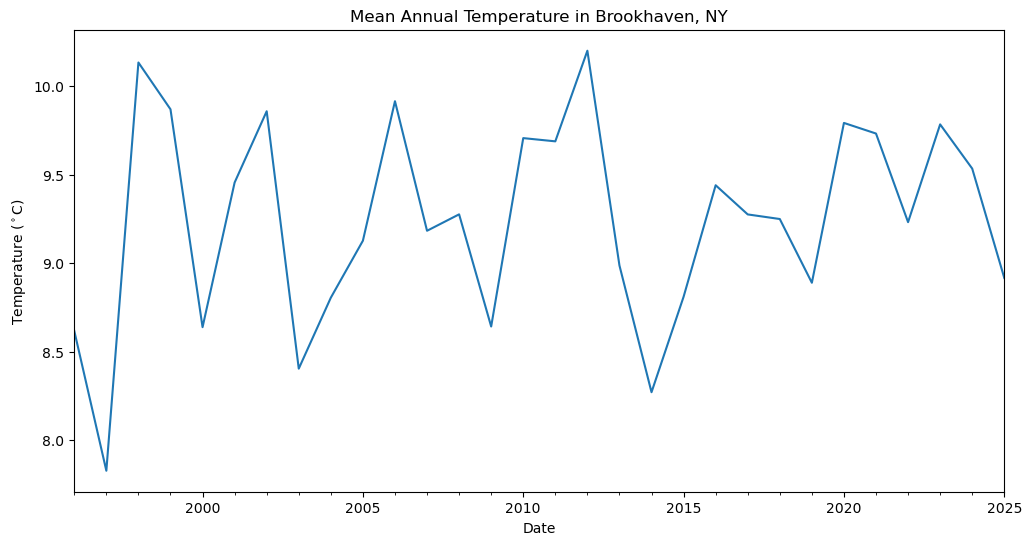

In [11]:
### Create a plot with the annual data
no_legend = ny_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Brookhaven, NY',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize= (12,6))

### call the no legend object and tell it to remove the legend
no_legend.legend().remove()

In [12]:
### Create interactive plot

### Fixes issue that is preventing plot from being viewed
hvplot.extension("bokeh")

### plot the annual data interactively
ny_ann_temp_plot = ny_ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Brookhaven, NY',
    xlabel = 'Year',
    ylabel = 'Temperature (degree C)'
)

### Show the plot
ny_ann_temp_plot



:Curve   [DATE]   (temp_c)

#### Plot Description
The plot of the mean annual temperatures in Brookhaven helps visualize changing mean annual temperatures from year to year. The minimum temperature is 7.8&deg;C and occurs in 1997, while the max temperature is 10.2&deg;C and occurs in 2012. To get a better idea of how quickly the temperature is changing from year to year, an ordinary least squares (OLS) regression can be performed.

In [13]:
### Save the plot as an html
hv.save(ny_ann_temp_plot, 'annual_temp_brookhaven.html')

In [14]:
### subset data to just include celsius
ny_ann_temp_c_df = ny_ann_temp_df[['temp_c']]

### open dataframe
ny_ann_temp_c_df

,temp_c
DATE,
1996-01-01,8.616704
1997-01-01,7.826752
1998-01-01,10.133517
1999-01-01,9.869102
2000-01-01,8.637894
2001-01-01,9.455307
2002-01-01,9.858025
2003-01-01,8.403558
2004-01-01,8.804619


### Data Analysis

In [15]:
### Steps to run a regression

### subset data to just include celsius
ny_ann_temp_c_df = ny_ann_temp_df[['temp_c']]

### Fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = ny_ann_temp_c_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = ny_ann_temp_c_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print the slope
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.01188033] degrees per year


#### Temperature Change
Temperature readings from 1996 to 2025 at the UPTON COOP NWSFO NEW YORK station, indicate that Brookhaven, NY has warmed by about 0.01&deg;C per year.

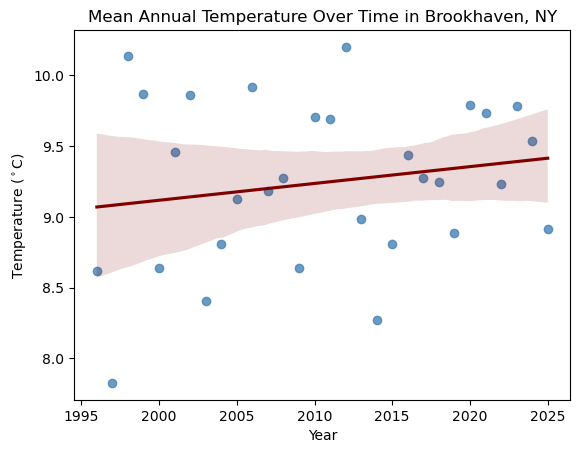

In [16]:
### plot data
ax = sns.regplot(
    x = ny_ann_temp_c_df.index.year, 
    y = ny_ann_temp_c_df.temp_c,

    ### change the color of the data points
    color = 'steelblue',

    ### change the color of the trendline
    line_kws = {'color': 'maroon'},
)

### make labels
ax.set(
    title = 'Mean Annual Temperature Over Time in Brookhaven, NY',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall/brookhaven_temp_trend.jpeg')

### plot it
plt.show()

### Temperature Data Show Temperatures have Increased Over a 30 Year Period in Brookhaven, NY

According to the OLS regression, Brookhaven has warmed an average of 0.01&deg;C per year from 1996 to 2025. A Climate Impact Spotlight conducted by the New York State Climate Impacts Assessment on the Long Island Region projects that Long Island temperatures will increase between 2.1&deg;C and 3.2&deg;C by 2050, which is a greater rate of increase than this regression predicts. The discrepancy can be due to a few reasons:
<ol>
    <li>The regression assumes linearity or that temperature will increase or decrease at a constant rate, which may not be the case.</li>
    <li>The regression was performed for 30 data points. More data points could make the rate of increase more reliable.</li>
    <li>While a coefficient of determination(r-squared value) was not determined, the data points seem mostly randomly scattered. This indicates that the variance in the temperature may be better explained by another variable.</li>
</ol>


Climate is caused by multiple factors often coupled with each other, which is one of the reasons why trying to determine trends in climate change can be difficult (Giorgi, 2005). Still multiple sources agree that the Long Island region is at a huge risk for climate change impacts, including rising sea levels, warming ocean temperatures, and ocean acidification.

Bibliography
* Menne, M. J., Durre, I., Korzeniewski, B., McNeill, S., Thomas, K., Yin, X., Anthony, S., Ray, R., Vose, R. S., Gleason, B. E., & Houston, T. G. (2012). Global Historical Climatology Network – Daily (GHCN-Daily), Version 3: Upton, NY (USC00308721), 1996–2025. NOAA National Centers for Environmental Information. [doi:10.7289/V5D21VHZ](doi:10.7289/V5D21VHZ)
* Matthew J. Menne, Imke Durre, Russell S. Vose, Byron E. Gleason, and Tamara G. Houston, 2012: An Overview of the Global Historical Climatology Network-Daily Database. J. Atmos. Oceanic Technol., 29, 897-910. [doi:10.1175/JTECH-D-11-00103.1](doi:10.1175/JTECH-D-11-00103.1)
* Dike, J., & Tilburg, C. (2007). Climatic timescale temperature and precipitation increases on long Island, New York. Atmosphere-Ocean, 45(2), 93–105. [https://doi.org/10.3137/ao.450203[(https://doi.org/10.3137/ao.450203)]
* New York State Climate Impacts Assessment. (2024). Climate Impact Spotlight: Long Island [Fact sheet]. NYSERDA. [https://nysclimateimpacts.org/wp-content/uploads/2025/12/Climate-Region-Long-Island_508.pdf](https://nysclimateimpacts.org/wp-content/uploads/2025/12/Climate-Region-Long-Island_508.pdf)
* Giorgi, F. (2005). Climate Change Prediction. Climatic Change, 73(3), 239–265. [https://doi.org/10.1007/s10584-005-6857-4](https://doi.org/10.1007/s10584-005-6857-4)
